## 查看能量分布，记得去掉尾部的0padding,同时傅里叶之前经过COS函数。

Source Shape: (19439, 10000)
Processing Class 0 with 194 samples...


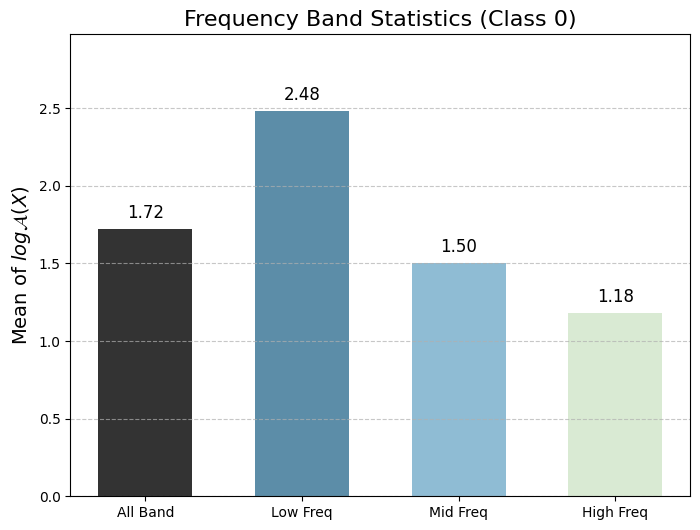

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# 设置中文字体和绘图风格（可选）
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# ======================
# 1. 加载原始数据
# ======================
path = "./datasets/TemporalDrift/train.npz"
data = np.load(path)

X_s, y_s = data['X'], data['y']
print("Source Shape:", X_s.shape)

# ======================
# 2. 数据预处理与FFT (幅度谱)
# ======================
def get_log_amplitude_stats(X):
    """
    输入: X shape [N, T]
    输出: 各频段的平均 log(幅度)
    """
    # 复制并处理数据
    X = X.copy()
    mask = (X != 0)
    # X[mask] = np.cos(X[mask])
    X[mask] = np.cos(X[mask])
    

    # FFT: 计算幅度谱 (注意这里没有平方)
    # rfft 输出形状为 [N, T//2 + 1]
    X_fft = np.fft.rfft(X, axis=1)
    X_amp = np.abs(X_fft)

    # 计算 Log 幅度: log(A(X))
    # 加一个极小值 1e-8 防止 log(0)
    log_amp = np.log(X_amp + 1e-8)

    # ======================
    # 3. 频段划分与统计
    # ======================
    n_freq = log_amp.shape[1]

    # 定义频段索引 (参照你的三分法)
    low_end = n_freq // 3
    mid_end = 2 * n_freq // 3

    # 计算每个样本在每个频段的平均值，然后在所有样本上取平均
    # axis=1 表示在频率维度上求平均

    # 全频段 (All Band)
    mean_all = log_amp.mean()

    # 低频段
    mean_low = log_amp[:, :low_end].mean()

    # 中频段
    mean_mid = log_amp[:, low_end:mid_end].mean()

    # 高频段
    mean_high = log_amp[:, mid_end:].mean()

    return [mean_all, mean_low, mean_mid, mean_high]

# 假设你想画所有类别的平均情况，或者只画类别0
# 这里为了演示，我们只取类别 0 (如你原代码所示)
cls = 0
X_cls = X_s[y_s == cls]
print(f"Processing Class {cls} with {X_cls.shape[0]} samples...")

# 获取统计数据
stats = get_log_amplitude_stats(X_cls)
labels = ['All Band', 'Low Freq', 'Mid Freq', 'High Freq']

# ======================
# 4. 绘制柱状图
# ======================
plt.figure(figsize=(8, 6))

# 创建柱状图
bars = plt.bar(labels, stats, color=['#333333', '#5c8da8', '#8fbcd4', '#d9ead3'], width=0.6)

# 添加数值标签在柱子上方
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.05, f'{yval:.2f}',
             ha='center', va='bottom', fontsize=12)

plt.ylabel(r'Mean of $log \mathcal{A}(X)$', fontsize=14)
plt.title(f'Frequency Band Statistics (Class {cls})', fontsize=16)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, max(stats) * 1.2) # 留出空间给文字标签

plt.show()

In [7]:
print(data['X'][:5])

[[ 1.00000000e-06 -3.00292833e-03  2.11027907e-01 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [-1.00000000e-06  4.07980515e-04 -2.95280980e-01 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [-1.00000000e-06  4.57094742e-04 -3.22686003e-01 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 1.00000000e-06 -3.20498036e-01  3.20950078e-01 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [-1.00000000e-06  3.05609567e-03 -2.64965104e-01 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]]


## 不进行COS函数转化为周期信号，好像也可以进行FFT但要进行归一化

原始数据形状: (19439, 10000)
类别 0 的数据形状: (194, 10000)


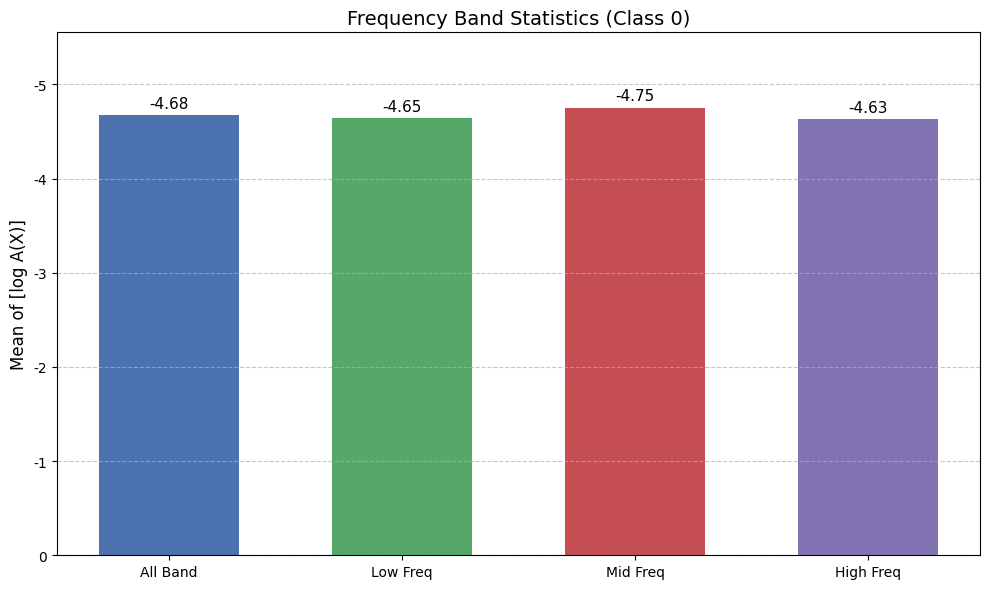

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import os

# ======================
# 1. 配置与加载
# ======================
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

path = "./datasets/TemporalDrift/train.npz"

if not os.path.exists(path):
    raise FileNotFoundError(f"文件未找到: {path}")

data = np.load(path)
X_s, y_s = data['X'], data['y']

print(f"原始数据形状: {X_s.shape}")

# ======================
# 2. 定义频段分析函数 (保持不变)
# ======================
def analyze_frequency_bands(X, band_name="All Band"):
    """
    计算输入数据的平均对数幅度
    """
    # 1. 预处理
    X_proc = X.copy()

    # 2. FFT 变换
    X_fft = np.fft.rfft(X_proc, axis=1)
    
    # 3. 计算幅度谱 A(X)
    amplitude = np.abs(X_fft)
    
    # L2 归一化 (在频率轴上归一化，保持每个样本的相对频谱形状)
    # 注意：axis=1 表示对每个样本的频率向量进行归一化
    norm_factor = np.linalg.norm(amplitude, axis=1, keepdims=True)
    amplitude = amplitude / (norm_factor + 1e-9)
    
    # 4. 计算对数幅度 log(A(X))
    log_amp = np.log(amplitude + 1e-8)

    # 5. 在样本维度求平均
    mean_log_amp_per_freq = np.mean(log_amp, axis=0)

    # 6. 划分频段并计算该频段的平均值
    n_freq = len(mean_log_amp_per_freq)
    low_end = n_freq // 3
    mid_end = 2 * n_freq // 3

    val_all = np.mean(mean_log_amp_per_freq)
    val_low = np.mean(mean_log_amp_per_freq[:low_end])
    val_mid = np.mean(mean_log_amp_per_freq[low_end:mid_end])
    val_high = np.mean(mean_log_amp_per_freq[mid_end:])

    return [val_all, val_low, val_mid, val_high]

# ======================
# 3. 数据筛选与执行分析
# ======================

# --- 修改点：筛选类别 0 ---
target_class = 0
mask = (y_s == target_class)
X_cls_0 = X_s[mask]

print(f"类别 {target_class} 的数据形状: {X_cls_0.shape}")

# 使用筛选后的数据进行计算
stats = analyze_frequency_bands(X_cls_0, band_name=f"Class {target_class}")

# ======================
# 4. 绘制柱状图
# ======================
labels = ['All Band', 'Low Freq', 'Mid Freq', 'High Freq']
x = np.arange(len(labels))
width = 0.6

fig, ax = plt.subplots(figsize=(10, 6))
# 使用更柔和的颜色以匹配论文风格
colors = ['#4c72b0', '#55a868', '#c44e52', '#8172b2']
rects1 = ax.bar(x, stats, width, color=colors)

ax.set_ylabel('Mean of [log A(X)]', fontsize=12)
ax.set_title(f'Frequency Band Statistics (Class {target_class})', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.set_ylim(0, max(stats) * 1.2) # 设置Y轴范围，防止标签被切掉

# 在柱子上方添加数值标签
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=11)

autolabel(rects1)

plt.tight_layout()
plt.show()

哦，不对，就是要看一个类别的，那就加个cos吧，我记得这个是从另一篇的得来的：
Domain Adaptation for Time Series Under Feature and Label Shifts：
受傅里叶神经算子（FNO）（Li等人，2021b）的启发，RAINCOAT对xi的傅里叶变换的低频模式进行卷积。我们对傅里叶卷积进行了两项修改以提高其在DA中的实用性：1）防止频率泄漏：离散傅里叶变换将输入xi视为周期性的。违反这种假设会导致频率泄漏（Harris，1978）。具体来说，给定两个窗口切片时间序列xsi和xti，应用DFT（1）可能会返回扰动和噪声的vsi和vti，这可能导致噪声偏差的领域对齐。为了防止在噪声频率特征上对齐，RAINCOAT在应用DFT之前应用平滑函数（余弦函数）。

## 看看跨域效果

正在处理跨域数据...
✅ 成功加载: Day 1 (Source) (Samples: 194)
✅ 成功加载: Day 14 (Samples: 223)
✅ 成功加载: Day 90 (Samples: 262)
✅ 成功加载: Day 270 (Samples: 195)


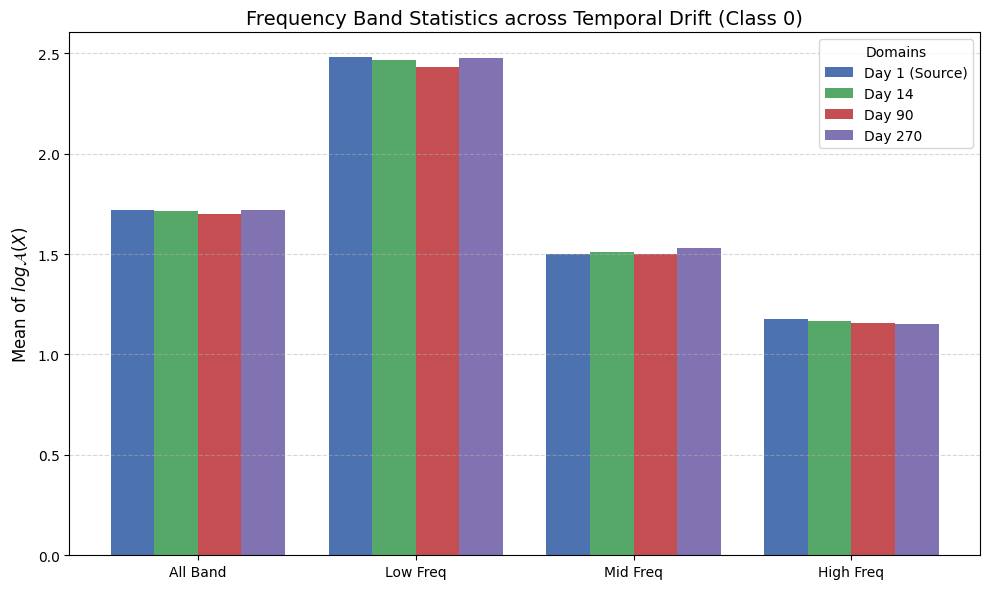

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import os

# ======================
# 1. 配置与路径设置
# ======================
base_dir = "./datasets/TemporalDrift/"

# 定义所有需要加载的时间点（域）
# 注意：请确保这些文件名与你文件夹里的实际文件名一致
domain_configs = [
    {"name": "Day 1 (Source)", "file": "train.npz"},
    {"name": "Day 14",         "file": "day14.npz"},
    {"name": "Day 90",         "file": "day90.npz"},
    {"name": "Day 270",        "file": "day270.npz"},
]

# 设置绘图风格
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# ======================
# 2. 核心分析函数 (保持不变)
# ======================
def get_log_amplitude_stats(X, apply_cos=True):
    """
    输入: X shape [N, T]
    输出: 各频段的平均 log(幅度)
    """
    X = X.copy()
    
    # RAINCOAT 风格预处理：加窗/平滑
    if apply_cos:
        mask = (X != 0)
        # 注意：这里对非零值应用 cos 变换
        # 原始 RAINCOAT 论文可能用的是更复杂的 window，但这里按你的逻辑用 cos
        X[mask] = np.cos(X[mask])

    # FFT: 计算幅度谱
    X_fft = np.fft.rfft(X, axis=1)
    X_amp = np.abs(X_fft)

    # 计算 Log 幅度
    log_amp = np.log(X_amp + 1e-8)

    # 频段划分
    n_freq = log_amp.shape[1]
    low_end = n_freq // 3
    mid_end = 2 * n_freq // 3

    # 计算统计值
    mean_all = log_amp.mean()
    mean_low = log_amp[:, :low_end].mean()
    mean_mid = log_amp[:, low_end:mid_end].mean()
    mean_high = log_amp[:, mid_end:].mean()

    return [mean_all, mean_low, mean_mid, mean_high]

# ======================
# 3. 循环加载数据并计算统计量
# ======================
all_stats = []
valid_domains = [] # 用于存储成功加载的域名

print("正在处理跨域数据...")

for domain in domain_configs:
    path = os.path.join(base_dir, domain["file"])
    
    if os.path.exists(path):
        try:
            data = np.load(path)
            X = data['X']
            y = data['y']
            
            # 这里为了模仿 HAP 的图，我们通常看整体分布，或者指定某一个类
            # 假设我们看 Class 0 (如果数据里有标签的话)
            # 如果要看整体，直接用 X 即可
            cls = 0
            if cls in y:
                X_cls = X[y == cls]
            else:
                X_cls = X # 如果没有该类，用所有数据兜底
                
            stats = get_log_amplitude_stats(X_cls)
            all_stats.append(stats)
            valid_domains.append(domain["name"])
            print(f"✅ 成功加载: {domain['name']} (Samples: {X_cls.shape[0]})")
            
        except Exception as e:
            print(f"❌ 处理 {domain['name']} 时出错: {e}")
    else:
        print(f"⚠️ 文件未找到: {path}")

# 将列表转换为 numpy 数组以便绘图: shape [Num_Domains, 4]
all_stats = np.array(all_stats)

# ======================
# 4. 绘制 HAP 风格分组柱状图
# ======================
if len(all_stats) > 0:
    labels = ['All Band', 'Low Freq', 'Mid Freq', 'High Freq']
    x = np.arange(len(labels))  # 横坐标位置
    width = 0.2  # 柱子的宽度 (因为有4个域，所以设窄一点)

    fig, ax = plt.subplots(figsize=(10, 6))

    # 定义颜色 (模仿 HAP 的蓝/红/绿 色系，这里用一套渐变蓝)
    # 你可以根据喜好修改 colors 列表
    colors = ['#4c72b0', '#55a868', '#c44e52', '#8172b2'] 
    # 如果域的数量不等于4，自动截取或循环颜色
    colors = colors[:len(valid_domains)] 

    # 循环绘制每个域的柱子
    for i, domain_name in enumerate(valid_domains):
        # 计算每个域柱子的偏移量
        # 例如：-1.5*width, -0.5*width, +0.5*width, +1.5*width
        offset = (i - len(valid_domains) / 2) * width + width/2
        rects = ax.bar(x + offset, all_stats[i], width, label=domain_name, color=colors[i])

    # 添加标签、标题和图例
    ax.set_ylabel(r'Mean of $log \mathcal{A}(X)$', fontsize=12)
    ax.set_title('Frequency Band Statistics across Temporal Drift (Class 0)', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.legend(title="Domains")
    ax.grid(axis='y', linestyle='--', alpha=0.5)

    # 自动调整布局
    plt.tight_layout()
    plt.show()
else:
    print("没有数据可绘图，请检查文件路径。")

把同一个域的放一起

正在处理数据...
已加载: Day 1 (Source)
已加载: Day 14
已加载: Day 90
已加载: Day 270


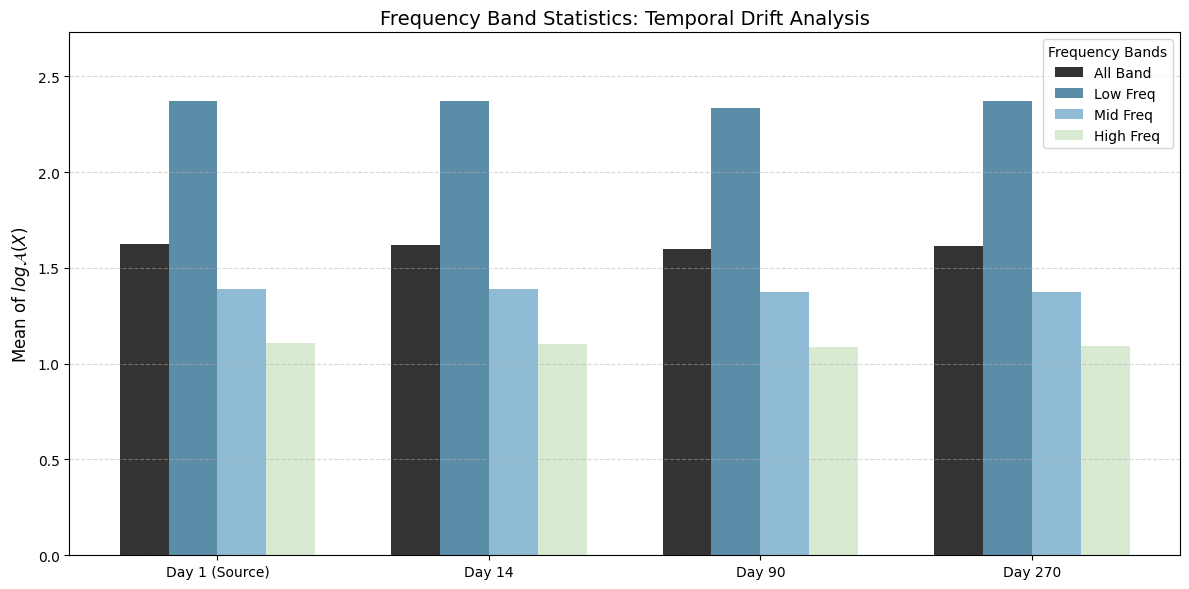

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import os

# ======================
# 1. 配置与路径设置
# ======================
base_dir = "./datasets/TemporalDrift/"

# 定义所有需要加载的时间点（域）
# 请确保这些文件名与你文件夹里的实际文件名一致
domain_configs = [
    {"name": "Day 1 (Source)", "file": "train.npz"},
    {"name": "Day 14",         "file": "day14.npz"},
    {"name": "Day 90",         "file": "day90.npz"},
    {"name": "Day 270",        "file": "day270.npz"},
]

# 保持你原来的颜色定义
# ['#333333', '#5c8da8', '#8fbcd4', '#d9ead3']
# 对应: All, Low, Mid, High
bar_colors = ['#333333', '#5c8da8', '#8fbcd4', '#d9ead3']
band_labels = ['All Band', 'Low Freq', 'Mid Freq', 'High Freq']

# 设置绘图风格
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# ======================
# 2. 核心分析函数
# ======================
def get_log_amplitude_stats(X, apply_cos=True):
    X = X.copy()
    
    # RAINCOAT 风格预处理：加窗/平滑
    if apply_cos:
        mask = (X != 0)
        X[mask] = np.cos(X[mask])
    
    # FFT 变换
    X_fft = np.fft.rfft(X, axis=1)
    X_amp = np.abs(X_fft)
    
    # 计算 Log 幅度
    log_amp = np.log(X_amp + 1e-8)
    
    # 频段划分
    n_freq = log_amp.shape[1]
    low_end = n_freq // 3
    mid_end = 2 * n_freq // 3
    
    # 统计各频段均值
    mean_all = log_amp.mean()
    mean_low = log_amp[:, :low_end].mean()
    mean_mid = log_amp[:, low_end:mid_end].mean()
    mean_high = log_amp[:, mid_end:].mean()
    
    return [mean_all, mean_low, mean_mid, mean_high]

# ======================
# 3. 批量加载与计算
# ======================
all_stats = []
valid_domains = []

print("正在处理数据...")
for cfg in domain_configs:
    path = os.path.join(base_dir, cfg["file"])
    if os.path.exists(path):
        try:
            data = np.load(path)
            X, y = data['X'], data['y']
            
            # 这里我们分析所有类别（如果你想只看 Class 0，可以加上 X = X[y==0]）
            # 为了展示整体漂移，通常看整体分布
            stats = get_log_amplitude_stats(X)
            all_stats.append(stats)
            valid_domains.append(cfg['name'])
            print(f"已加载: {cfg['name']}")
        except Exception as e:
            print(f"处理 {cfg['name']} 时出错: {e}")
    else:
        print(f"⚠️ 文件未找到: {path}")

# 转换为 numpy 数组以便绘图: shape = [num_domains, 4]
all_stats = np.array(all_stats)

# ======================
# 4. 绘制分组柱状图 (按域分组)
# ======================
if len(all_stats) > 0:

    num_domains = len(valid_domains)
    num_bands = len(band_labels)

    # x轴：每个域的位置
    x = np.arange(num_domains)

    width = 0.18

    fig, ax = plt.subplots(figsize=(12, 6))

    # ----------------------
    # 每个频段单独画
    # ----------------------
    for j in range(num_bands):

        # 第 j 个频段在所有域上的值
        values = all_stats[:, j]

        # 偏移
        offset = (j - (num_bands - 1) / 2) * width

        positions = x + offset

        ax.bar(
            positions,
            values,
            width,
            label=band_labels[j],
            color=bar_colors[j]
        )

    # ======================
    # 图表设置
    # ======================
    ax.set_ylabel(r'Mean of $log \mathcal{A}(X)$', fontsize=12)

    ax.set_title(
        'Frequency Band Statistics: Temporal Drift Analysis',
        fontsize=14
    )

    # 横轴变成域
    ax.set_xticks(x)
    ax.set_xticklabels(valid_domains)

    # 图例变成频段
    ax.legend(title="Frequency Bands", loc='upper right')

    ax.grid(axis='y', linestyle='--', alpha=0.5)

    # Y轴范围
    max_val = np.max(all_stats)
    ax.set_ylim(0, max_val * 1.15)

    plt.tight_layout()
    plt.show()

else:
    print("没有有效数据可绘制。")